# 서울시 119 이송 건수·인구 밀집 — 전처리 (1차 전처리 통합본)

**흐름** : 원본(`data`) 정리 → 이송 건수 정답 정리 → 시계열 분해 → 학습 데이터 생성 → 특성 선택 → 미래 예측용 입력 행

**읽는 파일**

| 폴더 | 파일 | 내용 |
|---|---|---|
| `data` | `자치구단위 서울생활인구 일별 집계표.csv` | 생활인구 (일별) |
| `data` | `119+구조활동+실적(구별)_20260921153018.csv` | 사고 원인별 구조 인원 (연별, KOSIS) |
| `data` | `2019년.xlsx` ~ `2024년.xlsx` | 의료이용 유출입 (연별) |
| `outputs` | `ambulance_monthly_cache.csv` | 이송 건수 정답 (01 수집 노트북 결과) |
| `outputs` | `realtime_er_beds.csv` · `safety_DSSP-IF-00606.csv` | 참고 표용 (01 수집 노트북 결과) |

**결과 파일 (`ml_data` 폴더)**

| 파일 | 내용 |
|---|---|
| `transport_dataset.csv` · `transport_selected.csv` · `transport_future.csv` | 이송 건수 학습 데이터 (자치구 × 월) · 선택 특성만 · 미래 입력 행 |
| `population_dataset.csv` · `population_selected.csv` | 인구 밀집 학습 데이터 (자치구 × 일) · 선택 특성만 |
| `features_transport.csv` · `features_population.csv` | 특성 선택 결과와 이유 |
| `ref_er_beds_realtime.csv` · `ref_er_institutions.csv` · `ref_beds_2014_2016.csv` | (참고용, 모델 미사용) 실시간 병상 · 응급실 운영기관 · 구별 병상 수 |

- 1차 전처리 결과(`population_rf` 등)는 csv로 저장하지 않고 메모리에서 바로 다음 단계로 사용

## 0. 환경 설정
- 경로 : `BASE_DIR` 하나만 바꾸면 나머지 폴더가 따라 바뀜
- 한글 폰트 : 운영체제별 폰트 파일 직접 등록 (`addfont`)
- `SELECT_END` : 특성 선택은 이 날짜 이전 데이터만 사용 (테스트 기간 정보 누출 방지)
- `FORECAST_MONTHS` : 미래 예측용 입력 행 개월 수

In [1]:
import os
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from IPython.display import display


def set_korean_font():
    candidates = [
        'C:/Windows/Fonts/malgun.ttf',                            # Windows
        '/System/Library/Fonts/Supplemental/AppleGothic.ttf',     # macOS
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',        # Linux
    ]
    for path in candidates:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            plt.rcParams['font.family'] = fm.FontProperties(fname=path).get_name()
            return
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans CJK JP']:
        if name in installed:
            plt.rcParams['font.family'] = name
            return


set_korean_font()
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

# 경로
BASE_DIR = Path(os.getenv('PROJECT_DIR', 'C:/ai/source/09_Project/cheolhyeon_jo'))
DATA_DIR = BASE_DIR / 'data'
OUT_DIR = BASE_DIR / 'outputs'
ML_DATA_DIR = BASE_DIR / 'ml_data'
RESULT_DIR = BASE_DIR / 'ml_result'
for d in [ML_DATA_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FORECAST_MONTHS = 6
SELECT_END = '2025-01-01'   # 예측 노트북의 테스트 시작일과 같게

GU_LIST = ['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구',
           '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구',
           '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']


def find_file(name, folders=(OUT_DIR,)):
    # name.csv 또는 '숫자_name.csv' 중 가장 최근 파일, 없으면 None
    found = [p for f in folders for p in list(Path(f).glob(name + '.csv')) + list(Path(f).glob('*_' + name + '.csv'))]
    return max(found, key=lambda p: p.stat().st_mtime) if found else None


def read_csv(path):
    df = pd.read_csv(path, encoding='utf-8-sig', low_memory=False).rename(columns={'district': 'District'})
    if 'ds' in df.columns:
        df['ds'] = pd.to_datetime(df['ds'], errors='coerce')
    return df


def save_csv(df, name):
    df.to_csv(ML_DATA_DIR / name, index=False, encoding='utf-8-sig')


def save_fig(name):
    plt.tight_layout()
    plt.savefig(RESULT_DIR / name, bbox_inches='tight')
    plt.show()

## 1. 원본 정리 (1차 전처리)

### 1-1. 생활인구 (자치구 × 일)
- 서울시 합계 행 제외 → 25개 자치구만
- 빠진 날짜 : 전체 날짜 × 자치구 조합으로 다시 만든 뒤(`reindex`) 구별 **선형보간**
- `pop_diff` : 주간 − 야간 인구

In [2]:
pop = pd.read_csv(DATA_DIR / '자치구단위 서울생활인구 일별 집계표.csv', encoding='cp949')
pop = pop[pop['시군구명'] != '서울시']
pop['ds'] = pd.to_datetime(pop['기준일ID'].astype(str), format='%Y%m%d')
pop = pop.rename(columns={'시군구명': 'District', '총생활인구수': 'total_pop',
                          '주간인구수(09~18)': 'day_pop', '야간인구수(19~08)': 'night_pop'})
pop = pop.set_index(['District', 'ds']).drop(columns=['기준일ID', '시군구코드'])

all_days = pd.date_range(pop.index.get_level_values('ds').min(), pop.index.get_level_values('ds').max())
pop = pop.reindex(pd.MultiIndex.from_product([GU_LIST, all_days], names=['District', 'ds']))
pop = pop.groupby(level='District').transform(lambda s: s.interpolate(limit_direction='both')).reset_index()
pop['pop_diff'] = pop['day_pop'] - pop['night_pop']
pop_cols = [c for c in pop.columns if c not in ['ds', 'District']]
print('생활인구 :', pop.shape, pop['ds'].min().date(), '~', pop['ds'].max().date())

생활인구 : (76000, 15) 2018-04-05 ~ 2026-07-31


### 1-2. 사고 원인별 구조 인원 (자치구 × 연도)
- KOSIS 표 구조 : 컬럼명 = 연도, 1~3행 = 대분류 / 중분류 / 사고 원인, 4행부터 = 자치구별 값
- 헤더 3행을 뒤집어(`.T`) 컬럼 정보 표로 만들고 `구조인원 > 사고종별구조인원`만 선택
- 와이드 → 롱(`melt`) → 원인별 컬럼(`pivot_table`) = One-Hot 형태
- 원인명 표준화 : 연도별 표기 차이 통일, 정의되지 않은 원인은 `기타/미상`
- `-` 등 숫자가 아닌 값 → 0

In [3]:
CAUSE_MAP = {'화재': '화재', '교통사고': '교통사고', '수난사고': '수난사고', '기계사고': '기계사고',
             '건물사고': '건물사고', '승강기사고': '승강기사고', '산악사고': '산악사고', '인명갇힘': '인명갇힘',
             '폭발사고': '폭발사고', '잠금장치 개방': '잠금장치개방', '안전조치': '안전조치',
             '자살추정': '자살추정', '위치추적': '위치추적'}

df = pd.read_csv(DATA_DIR / '119+구조활동+실적(구별)_20260921153018.csv', encoding='utf-8-sig')
head = df.iloc[:3, 2:].T.apply(lambda s: s.str.strip())
head.columns = ['구분1', '구분2', '원인']
head['연도'] = head.index.str[:4].astype(int)     # '2006.1' → 2006
head = head[(head['구분1'] == '구조인원 (명)') & (head['구분2'] == '사고종별구조인원') & (head['원인'] != '소계')]

body = df.iloc[3:].set_index(df.columns[1])
body = body.loc[body.index.isin(GU_LIST), head.index].rename_axis('District').reset_index()
long = body.melt(id_vars='District', var_name='컬럼', value_name='구조인원').join(head, on='컬럼')
long['구조인원'] = pd.to_numeric(long['구조인원'].str.replace(',', ''), errors='coerce').fillna(0)
long['원인'] = long['원인'].map(CAUSE_MAP).fillna('기타/미상')

acc_year = long.pivot_table(index=['연도', 'District'], columns='원인', values='구조인원',
                            aggfunc='sum', fill_value=0).reset_index()
acc_year.columns.name = None
print('사고 원인 :', acc_year.shape, acc_year['연도'].min(), '~', acc_year['연도'].max())

사고 원인 : (500, 16) 2006 ~ 2025


### 1-3. 의료이용 유출입 (자치구 × 연도)
- 원본 : 환자 거주지 × 병원 소재지 조합별 입원 연인원 (연도별 xlsx 6개)
- 헤더 3행 → 컬럼명 하나로 : 중분류 빈칸 `ffill` + 소분류
- 숫자 변환 : `"54,493"` 같은 콤마 제거 후 `to_numeric`
- 2019~2020년 : 응급실 항목 없음 → 응급실 연인원 결측
- 수요(거주지 기준) → `유출률` / 공급(병원 소재지 기준) → `유입률`
- 파일 읽기에 몇 분 소요

In [4]:
TOTAL_COL = '입원 전체_입원 전체'
ER_COL = '진료분야별_응급실'


def read_medflow(year):
    # '2021년'으로 시작하는 xlsx 찾기 (한글 파일명 표기 차이 통일 : NFC)
    name = next(n for n in os.listdir(DATA_DIR)
                if unicodedata.normalize('NFC', n).startswith(f'{year}년') and n.lower().endswith('.xlsx'))
    raw = pd.read_excel(DATA_DIR / name, header=None)
    group = raw.iloc[1].ffill()
    ids = [f'{side}_{field}' for side in ['환자', '병원'] for field in ['코드', '시도', '중진료권', '시군구']]
    data = raw.iloc[3:].reset_index(drop=True)
    data.columns = ids + [f'{group[i]}_{raw.iloc[2, i]}' for i in range(8, raw.shape[1])]
    data = data.loc[:, data.columns != 'nan_nan']                 # 끝에 붙은 빈 열 제거
    data = data[(data['환자_시도'] == '서울특별시') | (data['병원_시도'] == '서울특별시')].copy()
    for c in [TOTAL_COL, ER_COL]:
        data[c] = pd.to_numeric(data[c].astype(str).str.replace(',', '').str.strip(), errors='coerce') \
            if c in data.columns else np.nan
    return data.assign(연도=year)[['연도'] + ids + [TOTAL_COL, ER_COL]]


def flow_table(df, home, other, names):
    # home 쪽이 서울인 행을 home 시군구별로 합계 / names : [총, 서울내, 서울외, 비율, 응급실]
    d = df[df[f'{home}_시도'] == '서울특별시']
    d = d.assign(서울내=d[TOTAL_COL].where(d[f'{other}_시도'] == '서울특별시', 0))
    g = d.groupby(['연도', f'{home}_시군구'])
    t = pd.DataFrame({names[0]: g[TOTAL_COL].sum(), names[1]: g['서울내'].sum(), names[4]: g[ER_COL].sum(min_count=1)})
    t[names[2]] = t[names[0]] - t[names[1]]
    t[names[3]] = (t[names[2]] / t[names[0]]).round(4)
    return t[names].rename_axis(['연도', 'District']).reset_index()


medflow = pd.concat([read_medflow(y) for y in range(2019, 2025)], ignore_index=True)
demand = flow_table(medflow, '환자', '병원', ['총입원연인원', '서울내입원연인원', '서울외유출연인원', '유출률', '응급실입원연인원'])
supply = flow_table(medflow, '병원', '환자', ['총처리연인원', '서울내환자연인원', '서울외유입연인원', '유입률', '응급실처리연인원'])
medical = demand.merge(supply, on=['연도', 'District'], how='outer')
display(medical.head())

,연도,District,총입원연인원,서울내입원연인원,서울외유출연인원,유출률,응급실입원연인원,총처리연인원,서울내환자연인원,서울외유입연인원,유입률,응급실처리연인원
0,2019,강남구,1002129,582232,419897,0.4190,NaN,2201848,853651,1348197,0.6123,NaN
1,2019,강동구,915412,637381,278031,0.3037,NaN,1516483,879553,636930,0.4200,NaN
2,2019,강북구,910537,692635,217902,0.2393,NaN,514534,405141,109393,0.2126,NaN
3,2019,강서구,1419243,895605,523638,0.3690,NaN,853664,615640,238024,0.2788,NaN
4,2019,관악구,1141886,804299,337587,0.2956,NaN,524411,418800,105611,0.2014,NaN


### 1-4. 이송 건수 정답 (01 수집 노트북 결과)
- `outputs/ambulance_monthly_cache.csv` : 소방청 구급통계 API, 소방서 관할 기준, 2017~2025년

In [5]:
api = read_csv(OUT_DIR / 'ambulance_monthly_cache.csv')
print('API :', api.shape)

API : (2634, 5)


## 2. 이송 건수 정답 데이터 (자치구 × 월)

**소방서 신설로 관할이 바뀐 구간**
- 성동소방서 신설 전(~2017.7) : 성동구 출동이 광진구에 합산
- 금천소방서 신설 전(~2022.1) : 금천구 출동이 구로구에 합산
- 처리 : 해당 4개 구는 관할이 정리된 달부터 사용 (섞인 값·신설 첫 달 부분 집계 제외)
- 효과 : 광진·구로의 가짜 "급감", 성동·금천의 가짜 "급증" 방지

In [6]:
STATION_SPLIT = {'성동구': '2017-08-01', '광진구': '2017-08-01', '금천구': '2022-02-01', '구로구': '2022-02-01'}

start = pd.to_datetime(api['District'].map(STATION_SPLIT).fillna('2000-01-01'))
monthly = api[(api['ds'] >= start) & api['District'].isin(GU_LIST)].drop_duplicates(['ds', 'District'])
monthly = monthly.sort_values(['District', 'ds']).reset_index(drop=True)
monthly['출처'] = 'API'
print(f'사용 행 : {len(monthly)} ({monthly["ds"].min():%Y-%m} ~ {monthly["ds"].max():%Y-%m})')

사용 행 : 2564 (2017-01 ~ 2025-12)


### 2-1. 시계열 분해 (서울 전체 월별 이송 건수)
- `seasonal_decompose` : 실제값 = 추세(trend) + 계절성(seasonal) + 잔차(resid), 덧셈 모델, `period=12`
- 준비 조건 : 날짜 인덱스 + 빈 달 없이 연속 (`asfreq('MS')` + 보간)
- 서울 전체 합계 : 관할이 바뀌어도 합계는 같음 → 제외 전 API 원본 사용
- 결과 해석 : 계절 효과 폭이 월평균의 약 20% 이상 → `월`(원-핫)·`전년동월` 특성 유지

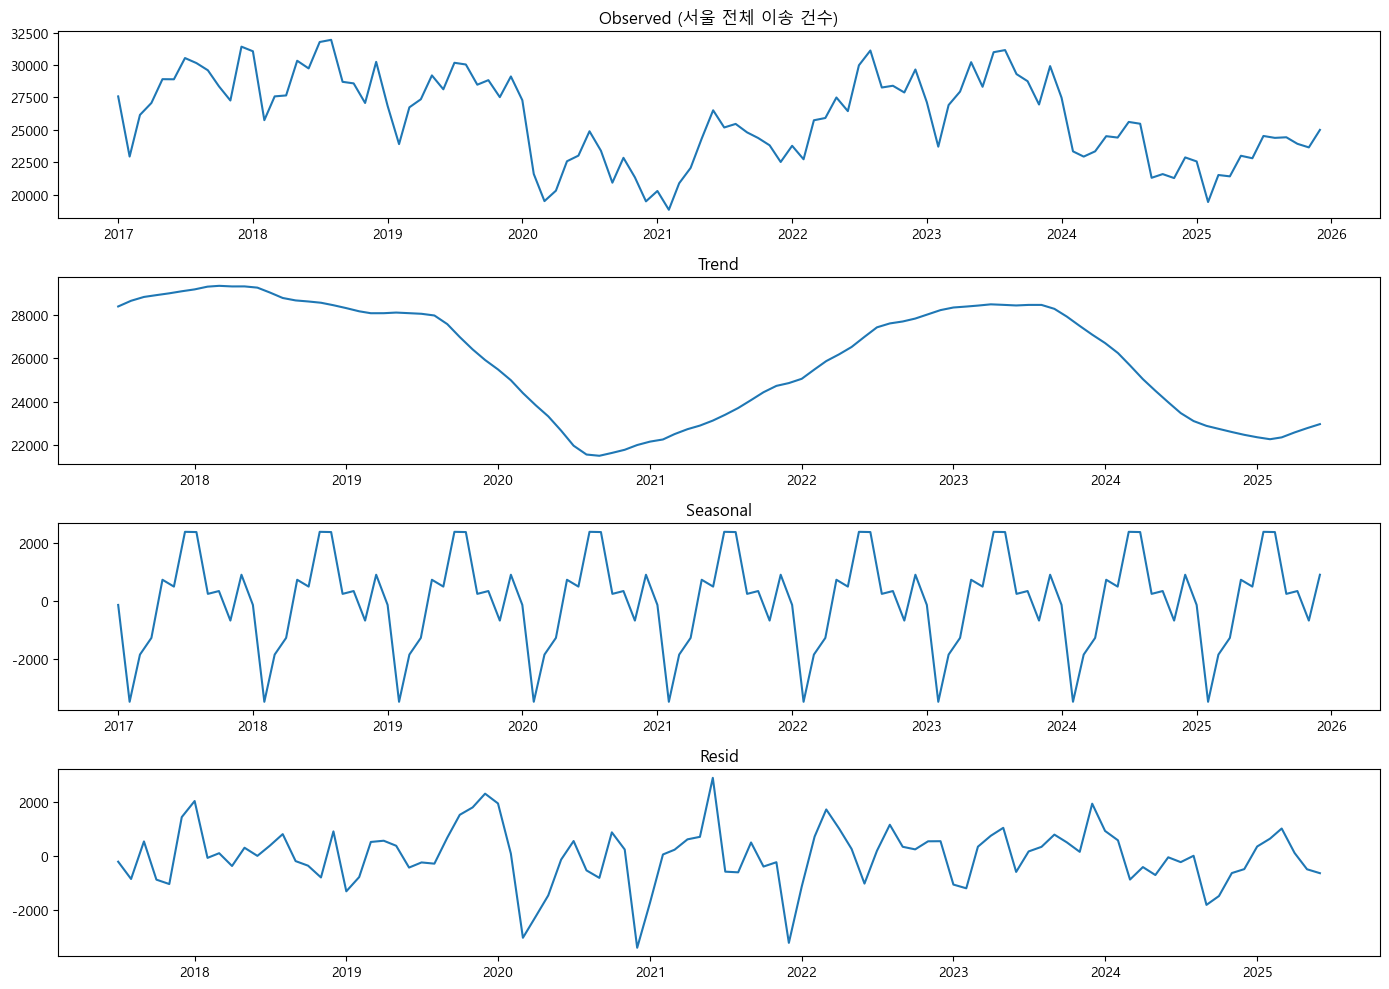

계절 효과 폭 : 5,835건 / 월평균 25,942건


In [7]:
city = api.groupby('ds')['transport_cnt'].sum().asfreq('MS').interpolate()
rslt = seasonal_decompose(city, period=12, model='additive')

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
for ax, (title, s) in zip(axes, [('Observed (서울 전체 이송 건수)', rslt.observed), ('Trend', rslt.trend),
                                 ('Seasonal', rslt.seasonal), ('Resid', rslt.resid)]):
    ax.plot(s)
    ax.set_title(title)
save_fig('transport_decompose.png')

season_by_month = rslt.seasonal.groupby(rslt.seasonal.index.month).mean()
print(f'계절 효과 폭 : {season_by_month.max() - season_by_month.min():,.0f}건 / 월평균 {city.mean():,.0f}건')

## 3. 참고 표 (모델 특성에서 제외)
- `realtime_er_beds` : 구별 응급의료기관 수 · 가용병상 합계 (웹 서비스 참고용)
- `DSSP-IF-00606` : 구별 병상 수 (2014~2016) → 연 단위·2016년에서 끝남, 2017년 값은 2016년 복사본이라 제외
- `DSSP-IF-10288` : 병·의원 목록 스냅샷 → 주소 두 번째 단어 = 자치구, `EMRO == 1` = 응급실 운영
- `reindex(GU_LIST, fill_value=0)` : 자료 없는 구도 0으로 포함
- 파일 위치 : `data` → `outputs` 순서로 찾음, 없으면 건너뜀

In [8]:
path = find_file('realtime_er_beds')
if path:
    beds = read_csv(path)
    bed_summary = (beds.groupby('District')
                       .agg(응급의료기관수=('Hospital_ID', 'nunique'), 가용병상수=('Available_Beds', 'sum'),
                            과밀기관수=('Is_Overcrowded', 'sum'), 정보노후기관수=('Is_Stale', 'sum'))
                       .reindex(GU_LIST, fill_value=0).rename_axis('District').reset_index())
    bed_summary['수집시각'] = beds['collected_at'].max()
    save_csv(bed_summary, 'ref_er_beds_realtime.csv')

GU_CODE = {
    '11110': '종로구', '11140': '중구', '11170': '용산구', '11200': '성동구', '11215': '광진구',
    '11230': '동대문구', '11260': '중랑구', '11290': '성북구', '11305': '강북구', '11320': '도봉구',
    '11350': '노원구', '11380': '은평구', '11410': '서대문구', '11440': '마포구', '11470': '양천구',
    '11500': '강서구', '11530': '구로구', '11545': '금천구', '11560': '영등포구', '11590': '동작구',
    '11620': '관악구', '11650': '서초구', '11680': '강남구', '11710': '송파구', '11740': '강동구',
}

path = find_file('safety_DSSP-IF-00606', (DATA_DIR, OUT_DIR))
if path:
    bed_stat = pd.read_csv(path, encoding='utf-8-sig', dtype={'DONG_CD': str})
    bed_stat['District'] = bed_stat['DONG_CD'].str[:5].map(GU_CODE)
    p = bed_stat.pivot_table(index='District', columns='YR', values='STATS_VL').drop(columns=2017, errors='ignore')
    p.columns = [f'병상수_{c}' for c in p.columns]
    save_csv(p.reindex(GU_LIST).reset_index(), 'ref_beds_2014_2016.csv')

path = find_file('safety_DSSP-IF-10288', (DATA_DIR, OUT_DIR))
if path:
    hosp = pd.read_csv(path, encoding='utf-8-sig', usecols=['HSPTL_ID', 'ADDR', 'EMRO', 'PRMSN_SCKBD_CNT'],
                       low_memory=False)   # 큰 파일이라 필요한 컬럼만
    hosp['District'] = hosp['ADDR'].str.split().str[1]
    er = hosp[hosp['ADDR'].str.startswith('서울', na=False) & (hosp['EMRO'] == 1)].copy()
    er['허가병상수'] = pd.to_numeric(er['PRMSN_SCKBD_CNT'], errors='coerce').fillna(0)
    er_summary = (er.groupby('District')
                    .agg(응급실운영기관수=('HSPTL_ID', 'nunique'), 응급실기관_허가병상수=('허가병상수', 'sum'))
                    .reindex(GU_LIST, fill_value=0).rename_axis('District').reset_index())
    save_csv(er_summary, 'ref_er_institutions.csv')

## 4. 이송 건수 학습 데이터 (자치구 × 월)

예측 시점에 이미 알고 있는 **과거 값만** 특성으로 사용

| 특성 | 의미 |
|---|---|
| `전월_transport_cnt` | 지난달 이송 건수 |
| `전년동월_y`, `전년동월_transport_cnt` | 작년 같은 달 출동·이송 건수 |
| `전월_생활인구` | 지난달 생활인구 월평균 |
| `전년_사고원인` · `전년_의료이용` | 작년 원인별 구조 인원 · 유출률·유입률 |

- 과거 값 붙이는 원리 : 과거 표 날짜를 n개월(1년) 뒤로 민 다음 날짜·구 기준 병합
- 같은 함수로 미래 입력 행(7장)도 계산 → 학습과 예측의 계산 방식 일치
- `전월_y`(지난달 출동) 제외 : 미래 달의 출동 건수는 예측하지 않으므로 계산 불가

In [9]:
pop_month = pop.assign(ds=pop['ds'].dt.to_period('M').dt.to_timestamp())
pop_month = pop_month.groupby(['ds', 'District'], as_index=False)[pop_cols].mean()   # 일별 → 월평균


def add_past(df, past_df, cols, months, prefix):
    # months개월 전 값 붙이기
    past = past_df[['ds', 'District'] + cols].copy()
    past['ds'] = past['ds'] + pd.DateOffset(months=months)
    past.columns = ['ds', 'District'] + [prefix + c for c in cols]
    return df.merge(past, on=['ds', 'District'], how='left')


def add_last_year(df, year_df):
    # 연 단위 표를 '작년 값'으로 붙이기
    y = year_df.assign(연도=year_df['연도'] + 1)
    y.columns = [c if c in ['연도', 'District'] else '전년_' + c for c in y.columns]
    return df.merge(y, on=['연도', 'District'], how='left')


def make_transport_features(base, hist):
    df = base[['ds', 'District']].copy()
    df['연도'] = df['ds'].dt.year
    df['월'] = df['ds'].dt.month
    df = add_past(df, hist, ['transport_cnt'], 1, '전월_')
    df = add_past(df, hist, ['y', 'transport_cnt'], 12, '전년동월_')
    df = add_past(df, pop_month, pop_cols, 1, '전월_')
    return add_last_year(add_last_year(df, acc_year), medical)


hist = monthly[['ds', 'District', 'y', 'transport_cnt']]
target_rows = monthly[monthly['transport_cnt'].notna()]
transport_df = make_transport_features(target_rows, hist).merge(
    target_rows[['ds', 'District', '출처', 'transport_cnt']], on=['ds', 'District'])
transport_df = transport_df.sort_values(['District', 'ds']).reset_index(drop=True)
save_csv(transport_df, 'transport_dataset.csv')
display(transport_df.tail())

,ds,District,연도,월,전월_transport_cnt,전년동월_y,전년동월_transport_cnt,전월_total_pop,전월_내국인생활인구수,전월_장기체류외국인인구수,전월_단기체류외국인인구수,전월_일최대인구수,전월_일최소인구수,전월_day_pop,전월_night_pop,...,전년_잠금장치개방,전년_폭발사고,전년_화재,전년_총입원연인원,전년_서울내입원연인원,전년_서울외유출연인원,전년_유출률,전년_응급실입원연인원,전년_총처리연인원,전년_서울내환자연인원,전년_서울외유입연인원,전년_유입률,전년_응급실처리연인원,출처,transport_cnt
2559,2025-08-01,중랑구,2025,8,993.0,2157.0,967.0,332115.917242,325666.035129,5819.954571,629.927552,364492.726581,294889.851329,303959.787897,352227.438203,...,5,0,13,1008537.0,709276.0,299261.0,0.2967,129922.0,762508.0,569201.0,193307.0,0.2535,133360.0,API,926.0
2560,2025-09-01,중랑구,2025,9,926.0,1763.0,809.0,330988.594161,324598.049610,5858.001445,532.543119,361583.985365,295609.210284,304658.536584,349795.778145,...,5,0,13,1008537.0,709276.0,299261.0,0.2967,129922.0,762508.0,569201.0,193307.0,0.2535,133360.0,API,928.0
2561,2025-10-01,중랑구,2025,10,928.0,1751.0,801.0,330940.287970,324628.369530,5808.762683,503.155760,364404.597957,291994.342870,301505.090640,351965.428933,...,5,0,13,1008537.0,709276.0,299261.0,0.2967,129922.0,762508.0,569201.0,193307.0,0.2535,133360.0,API,944.0
2562,2025-11-01,중랑구,2025,11,944.0,1649.0,760.0,332109.469406,325626.492639,5903.367194,579.609581,364570.370971,295551.564974,305362.042090,351214.774632,...,5,0,13,1008537.0,709276.0,299261.0,0.2967,129922.0,762508.0,569201.0,193307.0,0.2535,133360.0,API,908.0
2563,2025-12-01,중랑구,2025,12,908.0,1787.0,830.0,331663.582193,325443.876787,5722.575353,497.130067,363742.282790,293469.374303,303500.056713,351780.386113,...,5,0,13,1008537.0,709276.0,299261.0,0.2967,129922.0,762508.0,569201.0,193307.0,0.2535,133360.0,API,970.0


## 5. 인구 밀집 학습 데이터 (자치구 × 일)
- 정답 : `일최대인구수`
- 특성 : 월·요일·주말 여부, 전일 생활인구, 7일 전 같은 요일의 일최대인구수
- 전일 값 원리 : 구별·날짜순 정렬 → 구별 `shift(1)`
- 빈 날짜 대비 : 날짜 차이가 1일(7일)이 아니면 빈 값 처리 (`where`)
- `요일`·`월`·`주말여부` : 상관계수 선택 대상에서 빼고 항상 저장

In [10]:
TARGET_POP = '일최대인구수'

pop_df = pop.sort_values(['District', 'ds']).reset_index(drop=True)
pop_df['월'] = pop_df['ds'].dt.month
pop_df['요일'] = pop_df['ds'].dt.dayofweek          # 0=월요일 ... 6=일요일
pop_df['주말여부'] = (pop_df['요일'] >= 5).astype(int)

g = pop_df.groupby('District')
one_day = (pop_df['ds'] - g['ds'].shift(1)) == pd.Timedelta(days=1)
seven_days = (pop_df['ds'] - g['ds'].shift(7)) == pd.Timedelta(days=7)
lag1 = g[pop_cols].shift(1).where(one_day, axis=0).add_prefix('전일_')
pop_df['7일전_' + TARGET_POP] = g[TARGET_POP].shift(7).where(seven_days)

population_df = pd.concat([pop_df[['ds', 'District', '월', '요일', '주말여부', '7일전_' + TARGET_POP]],
                           lag1, pop_df[[TARGET_POP]]], axis=1).dropna().reset_index(drop=True)
save_csv(population_df, 'population_dataset.csv')
print(population_df.shape)

(75825, 20)


## 6. 특성 선택 (상관계수 기준)
- 계산 기간 : `SELECT_END` 이전 행만 → 테스트 기간 정답이 특성 선택에 섞이지 않음
- 제외 기준 (순서대로)
  - 결측률 20% 초과 : 행 손실 방지
  - 정답과 |r| < 0.3 : 직선 관계 약함
  - 이미 고른 컬럼과 |r| ≥ 0.9 : 같은 정보 반복(다중공선성)
  - 추가 시 완전행 보존율 70% 미만 : 빈 값 겹침으로 행 과다 손실
- 빈 값은 평균·0으로 채우지 않음 : 시계열 왜곡 방지
- `월` : 상관계수 대신 원-핫으로 모델에 항상 포함 (계절 효과는 직선 관계가 아님)

[transport] 선택 변수 : ['전월_transport_cnt', '전년동월_transport_cnt', '전월_night_pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '전월_서울외유입인구수']


,컬럼,정답과_상관계수,결과,이유
0,전년_총입원연인원,NaN,제외,결측 36% > 20%
1,전년_서울내입원연인원,NaN,제외,결측 36% > 20%
2,전년_서울외유출연인원,NaN,제외,결측 36% > 20%
3,전년_유출률,NaN,제외,결측 36% > 20%
4,전년_응급실입원연인원,NaN,제외,결측 60% > 20%
5,전년_총처리연인원,NaN,제외,결측 36% > 20%
6,전년_서울내환자연인원,NaN,제외,결측 36% > 20%
7,전년_서울외유입연인원,NaN,제외,결측 36% > 20%
8,전년_유입률,NaN,제외,결측 36% > 20%
9,전년_응급실처리연인원,NaN,제외,결측 60% > 20%


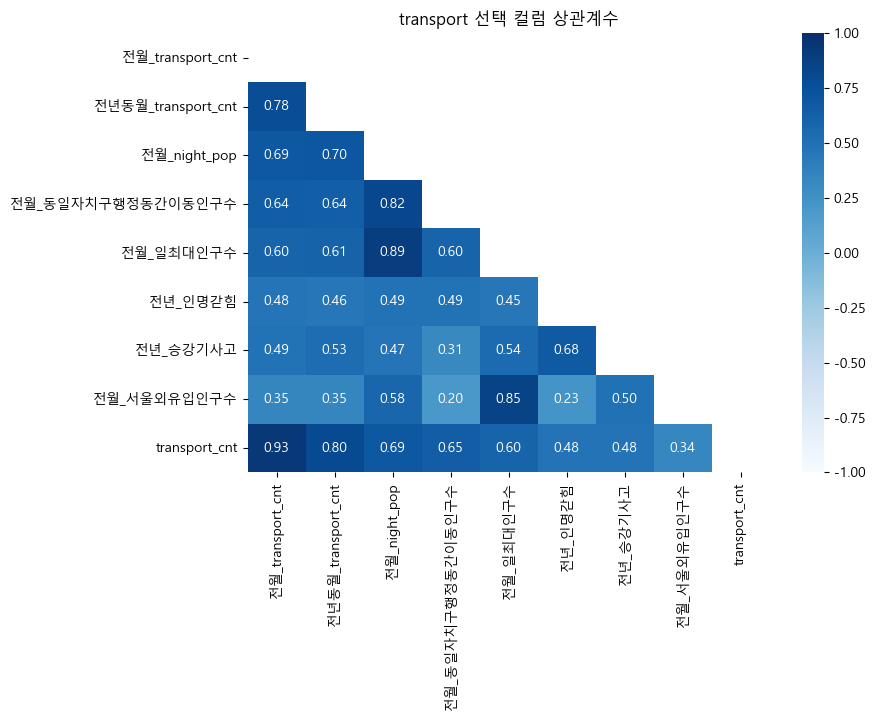

[population] 선택 변수 : ['7일전_일최대인구수', '전일_night_pop', '전일_일최대이동인구수', '전일_동일자치구행정동간이동인구수', '전일_pop_diff']


,컬럼,정답과_상관계수,결과,이유
0,7일전_일최대인구수,0.979625,선택,완전행 보존율 100%
1,전일_일최대인구수,0.959192,제외,7일전_일최대인구수와 너무 비슷함
2,전일_day_pop,0.949321,제외,7일전_일최대인구수와 너무 비슷함
3,전일_total_pop,0.942672,제외,7일전_일최대인구수와 너무 비슷함
4,전일_내국인생활인구수,0.929927,제외,7일전_일최대인구수와 너무 비슷함
5,전일_night_pop,0.871928,선택,완전행 보존율 100%
6,전일_일최소인구수,0.856459,제외,전일_night_pop와 너무 비슷함
7,전일_일최대이동인구수,0.838999,선택,완전행 보존율 100%
8,전일_서울외유입인구수,0.781991,제외,전일_일최대이동인구수와 너무 비슷함
9,전일_자치구간이동인구수,0.640685,제외,전일_일최대이동인구수와 너무 비슷함


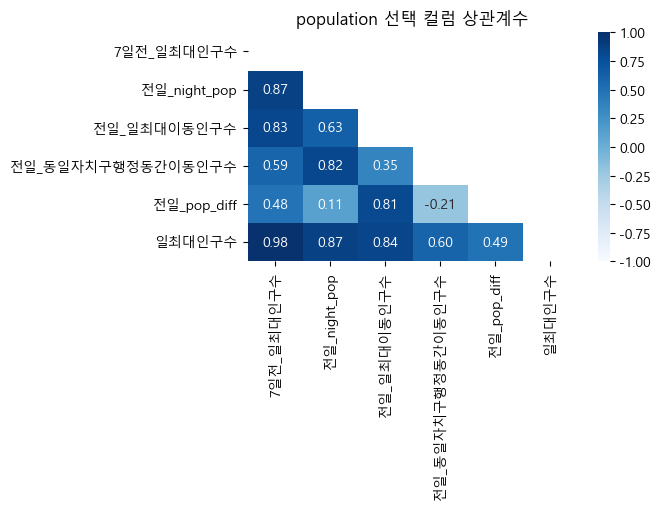

In [11]:
def select_features(df, target, candidates, min_corr=0.3, max_inter_corr=0.9, max_missing=0.20, min_retention=0.70):
    rows, selected = [], []
    missing = df[candidates].isna().mean()
    for col in missing[missing > max_missing].index:
        rows.append([col, np.nan, '제외', f'결측 {missing[col]:.0%} > {max_missing:.0%}'])

    usable = missing[missing <= max_missing].index.tolist()
    corr_target = df[usable].corrwith(df[target]).dropna()
    for col in corr_target.abs().sort_values(ascending=False).index:
        r = corr_target[col]
        similar = [s for s in selected if abs(df[col].corr(df[s])) >= max_inter_corr]
        retention = df[selected + [col, target]].notna().all(axis=1).mean()
        if abs(r) < min_corr:
            reason = f'정답과 상관 약함 (|r| < {min_corr})'
        elif similar:
            reason = f'{similar[0]}와 너무 비슷함'
        elif retention < min_retention:
            reason = f'추가 시 완전행 보존율 {retention:.0%} < {min_retention:.0%}'
        else:
            selected.append(col)
            rows.append([col, r, '선택', f'완전행 보존율 {retention:.0%}'])
            continue
        rows.append([col, r, '제외', reason])
    return selected, pd.DataFrame(rows, columns=['컬럼', '정답과_상관계수', '결과', '이유'])


topics = {
    'transport':  (transport_df,  'transport_cnt', ['ds', 'District', '출처', '월']),
    'population': (population_df, TARGET_POP,      ['ds', 'District', '월', '요일', '주말여부']),
}
selected_features = {}
for topic, (df, target, keys) in topics.items():
    candidates = [c for c in df.select_dtypes('number').columns if c not in keys + [target]]
    train_part = df[df['ds'] < SELECT_END]
    selected, result = select_features(train_part, target, candidates)
    selected_features[topic] = selected
    save_csv(result, f'features_{topic}.csv')
    save_csv(df[keys + selected + [target]].dropna(subset=selected + [target]), f'{topic}_selected.csv')
    print(f'[{topic}] 선택 변수 : {selected}')
    display(result)

    cols = selected + [target]
    corr = train_part[cols].corr()
    plt.figure(figsize=(2 + len(cols) * 0.8, 1 + len(cols) * 0.7))
    sns.heatmap(corr, vmin=-1, vmax=1, annot=True, fmt='.2f', cmap='Blues',
                mask=np.triu(np.ones_like(corr, dtype=bool)))
    plt.title(f'{topic} 선택 컬럼 상관계수')
    save_fig(f'fig_corr_{topic}.png')

## 7. 미래 예측용 입력 행 (`transport_future.csv`)
- 뼈대 : 마지막 실제 달 다음부터 `FORECAST_MONTHS`개월 × 25개 구
- 특성 계산 : 4장과 같은 `make_transport_features` 사용
- `전월_transport_cnt` : 첫 달만 실제 값, 이후는 빈 값 → 예측 노트북에서 재귀 예측값으로 채움
- 그 외 아직 없는 값(작년 의료이용 등) : 구별 가장 최근 값으로 채움 (`District.map`, 최근 수준 유지 가정)

In [12]:
future_months = pd.date_range(monthly['ds'].max() + pd.DateOffset(months=1), periods=FORECAST_MONTHS, freq='MS')
base = pd.DataFrame([(m, gu) for m in future_months for gu in GU_LIST], columns=['ds', 'District'])
future = make_transport_features(base, hist)

fill_cols = [c for c in future.columns if c not in ['ds', 'District', '연도', '월', '전월_transport_cnt']]
last_known = transport_df.sort_values('ds').groupby('District')[fill_cols].last()
for c in fill_cols:
    future[c] = future[c].fillna(future['District'].map(last_known[c]))

future = future.reindex(columns=[c for c in transport_df.columns if c not in ['출처', 'transport_cnt']])
save_csv(future.sort_values(['ds', 'District']), 'transport_future.csv')
print(f'예측 대상 : {future_months[0]:%Y-%m} ~ {future_months[-1]:%Y-%m}, {len(future)}행')

예측 대상 : 2026-01 ~ 2026-06, 150행
